In [1]:
import pandas as pd  
import os  
from statsmodels.tsa.seasonal import seasonal_decompose
from local_global import  series_decomp_multi
import torch
import matplotlib.pyplot as plt

folder_path = 'E:/故障诊断/数据集处理/1021/data/xi'  # 替换为你的Excel文件所在的文件夹路径  
all_files = os.listdir(folder_path)  
all_data = []  
  
for file in all_files:  
    if file.endswith('.xlsx'):  # 或者根据你的Excel文件扩展名进行修改  
        df = pd.read_excel(os.path.join(folder_path, file))  
        all_data.append(df)




In [2]:
print(len(all_data))

23


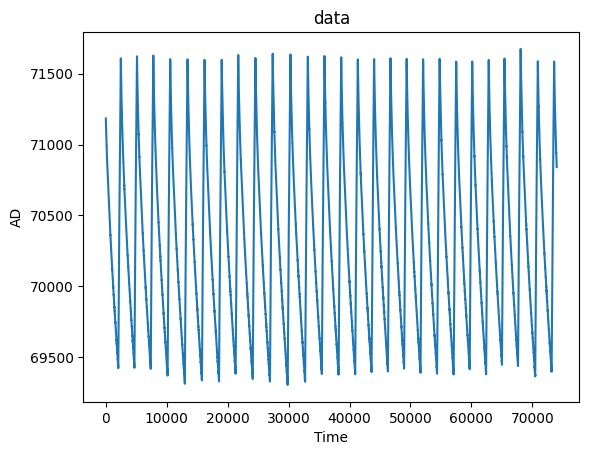

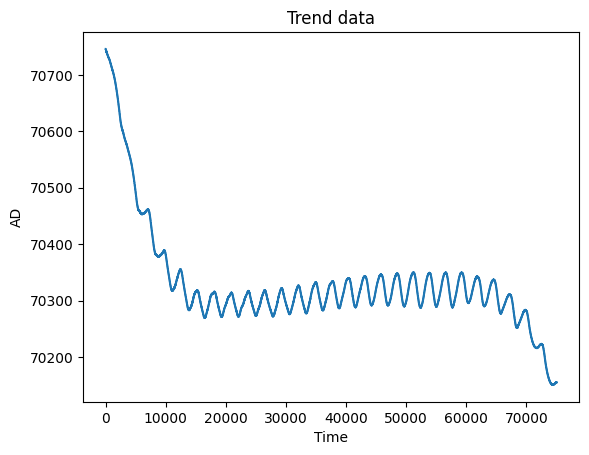

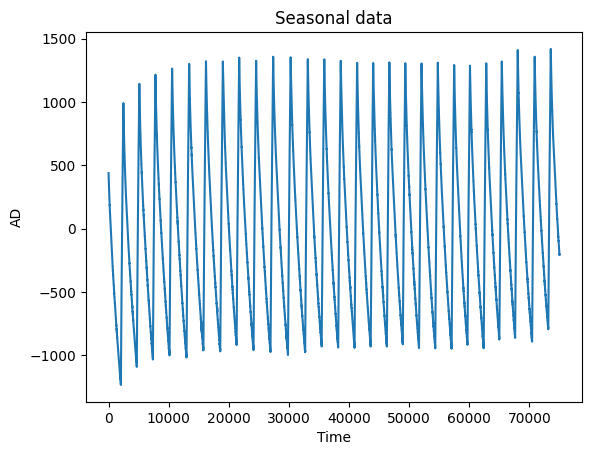

In [48]:

# 创建一个ExcelWriter对象  
writer = pd.ExcelWriter('E:/压力变送器引压管故障诊断/data/output_xi_1001_2001_3001.xlsx', engine='xlsxwriter')  

for i in range(len(all_data)):  
    data = all_data[i]  
    
    # 改变data数据类型为torch.tensor
    lenofdata = len(data)
    data_original = data[:74000]
    data = data.values.reshape(1, lenofdata, 1)
    data = torch.from_numpy(data)
    
    # decomp_multi = series_decomp_multi([1001,2001,3001]) # 多尺度
    # decomp_multi = series_decomp_multi([5001]) # 多尺度
    # decomp_multi = series_decomp_multi([10001]) # 多尺度
    decomp_multi = series_decomp_multi([10001,20001,30001]) # 多尺度
    seasonal_1, trend_1 = decomp_multi(data)
    
    # 改变trend_1 为dataframe
    trend_1 = trend_1.reshape(lenofdata, 1)
    trend_1 = trend_1.detach().numpy()
    trend_1 = pd.DataFrame(trend_1)
    # 改变seasonal_1 为dataframe
    seasonal_1 = seasonal_1.reshape(lenofdata, 1)
    seasonal_1 = seasonal_1.detach().numpy()
    seasonal_1 = pd.DataFrame(seasonal_1)
    # 将分解结果保存到Excel工作表中  
    trend_1.to_excel(writer, sheet_name=f'Sheet{i+1}', index=False)  
  
# 保存Excel文件  
writer.close()

plt.plot(data_original)
plt.xlabel('Time')
plt.ylabel('AD')
plt.title('data')

# Show the plot
plt.show()

plt.plot(trend_1)
plt.xlabel('Time')
plt.ylabel('AD')
plt.title('Trend data')

# Show the plot
plt.show()
plt.plot(seasonal_1)
plt.xlabel('Time')
plt.ylabel('AD')
plt.title('Seasonal data')

# Show the plot
plt.show()

c:\Users\zxf\.conda\envs\pytorch\Lib\site-packages\xlsxwriter\workbook.py:368: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


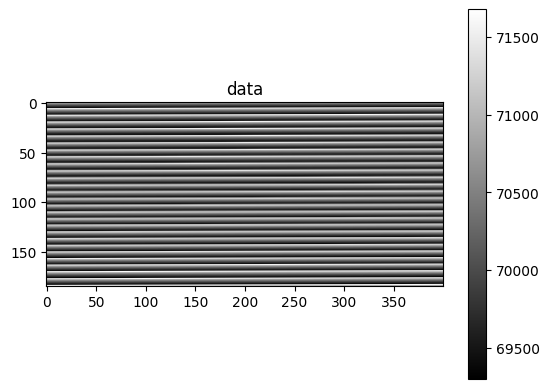

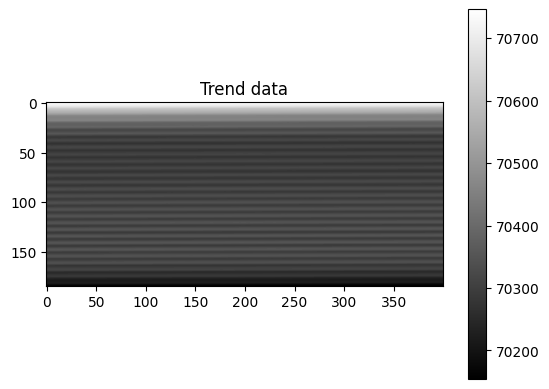

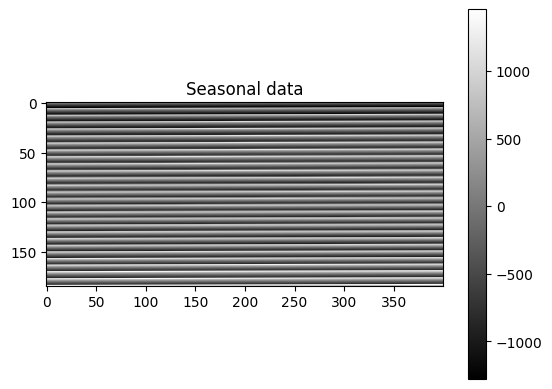

In [49]:
# 时间序列分解后的2维灰度图——成功
# 创建一个ExcelWriter对象  
writer_2D = pd.ExcelWriter('E:/压力变送器引压管故障诊断/data/output_xi_2D.xlsx', engine='xlsxwriter') 
for i in range(len(all_data)):  
    data_1D = all_data[i]  
    
    # 改变data数据类型为torch.tensor
    lenofdata = len(data_1D)

    data_original_1D = data_1D
    data_cut = data_original_1D.iloc[:74000]
    data_2D = data_cut.values.reshape(185,400)

    data_1D = data_1D.values.reshape(1, lenofdata, 1)
    data_1D = torch.from_numpy(data_1D)
    
    # decomp_multi = series_decomp_multi([1001,2001,3001]) # 多尺度
    # decomp_multi = series_decomp_multi([5001]) # 多尺度
    # decomp_multi = series_decomp_multi([10001]) # 多尺度
    # decomp_multi = series_decomp_multi([10001,20001,30001]) # 多尺度
    decomp_multi = series_decomp_multi([30001]) # 多尺度
    seasonal_1D, trend_1D = decomp_multi(data_1D)
    # 改变trend_1 为dataframe
    trend_1D = trend_1D.reshape(lenofdata, 1)
    trend_1D = trend_1D.detach().numpy()
    trend_1D = pd.DataFrame(trend_1)
    trend_1D_cut = trend_1D.iloc[:74000]
    trend_2D = trend_1D_cut.values.reshape(185,400)
    # 改变seasonal_1 为dataframe
    seasonal_1D = seasonal_1D.reshape(lenofdata, 1)
    seasonal_1D = seasonal_1D.detach().numpy()
    seasonal_1D = pd.DataFrame(seasonal_1D)
    seasonal_1D_cut = seasonal_1D.iloc[:74000]
    seasonal_2D = seasonal_1D_cut.values.reshape(185,400)
    # 将分解结果保存到Excel工作表中  
    #trend_1_2D.to_excel(writer_2D, sheet_name=f'Sheet{i+1}', index=False)  
  
writer.close()

plt.imshow(data_2D, cmap = 'gray')
plt.colorbar()
plt.title('data')
# Show the plot
plt.show()

plt.imshow(trend_2D, cmap = 'gray')
# plt.xlabel('Time')
# plt.ylabel('AD')
plt.colorbar()
plt.title('Trend data')
# Show the plot
plt.show()

plt.imshow(seasonal_2D, cmap = 'gray')
plt.colorbar()
plt.title('Seasonal data')
# Show the plot
plt.show()

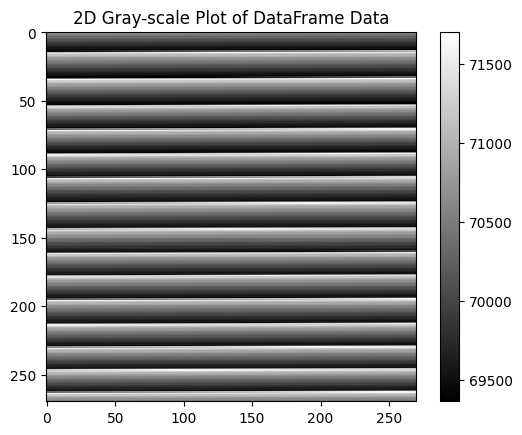

In [44]:
# 2维
# 创建一个ExcelWriter对象  
import numpy as np

file_path = 'E:/故障诊断/数据集处理/1021/data/xi/data_1022.xlsx'
data = pd.read_excel(file_path)

# writer_2D = pd.ExcelWriter('E:/压力变送器引压管故障诊断/data/output_xi_2D.xlsx', engine='xlsxwriter') 

    
    # 改变data数据类型为torch.tensor
# lenofdata = len(data)
# data = data.values.reshape(1, lenofdata, 1)
data_1 = data.values
data_1d = data_1[:72900]
# 计算二维数组的行数和列数
# 由于74000不是完全平方数，你可能需要决定如何分割这个数
# 例如，这里我们使用一个近似值：大约270x270
# rows = int(np.sqrt(data_1d.size))  # 假设是正方形
# cols = rows

# 确保rows*cols等于74000
rows = 270
cols = int(72900 / rows)

# 将一维数据reshape为二维数据
data_2d = data_1d.reshape((rows, cols))
# data_2D = data_cut.values.reshape(400,185)


# 绘制二维灰度图
plt.imshow(data_2d, cmap='gray', interpolation='nearest')  # 使用灰度颜色映射
plt.colorbar()  # 显示颜色条
plt.title('2D Gray-scale Plot of DataFrame Data')  # 添加标题

# 显示图表
plt.show()    
